In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [3]:
from pathlib import Path
from tqdm import tqdm

from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.pipeline.manifest_aptos import build_aptos_manifest
from src.retina_biomarkers.pipeline.stage2_geometry import (
    make_run_id_stage2, ODContext, stage2_geometry_one
)

APTOS_ROOT = Path("../../data/raw/APTOS2019")     
CACHE_ROOT = Path("../../outputs/aptos_cache")     # same as Stage 1

# IMPORTANT: this is the Stage1 run id you already used
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"     # <-- paste stage1 run id

cfg = PipelineConfig(image_size=512)              # keep SAME preprocess-related fields as Stage1
RUN_ID_STAGE2 = make_run_id_stage2(cfg, prefix="aptos2019")
print("RUN_ID_STAGE2:", RUN_ID_STAGE2)

items = build_aptos_manifest(APTOS_ROOT)
print("items:", len(items))

od_ctx = ODContext()  # loads model ONCE

ok = skip = fail = 0
for it in tqdm(items):
    try:
        r = stage2_geometry_one(
            image_id=it.image_id,
            cfg=cfg,
            cache_root=CACHE_ROOT,
            run_id_stage1=RUN_ID_STAGE1,
            run_id_stage2=RUN_ID_STAGE2,
            od_ctx=od_ctx,
            overwrite=False,
            save_preview_png=False,   # turn True for first 20 checks
        )
        if r["status"] == "ok": ok += 1
        else: skip += 1
    except Exception as e:
        fail += 1
        print("[FAIL]", it.image_id, e)

print(f"done. ok={ok} skipped={skip} fail={fail}")
print("stage2 cache:", CACHE_ROOT / RUN_ID_STAGE2 / "stage2")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


RUN_ID_STAGE2: aptos2019_stage2_793ded0a61
items: 3665


100%|██████████| 3665/3665 [1:06:44<00:00,  1.09s/it]    

done. ok=3665 skipped=0 fail=0
stage2 cache: ..\..\outputs\aptos_cache\aptos2019_stage2_793ded0a61\stage2


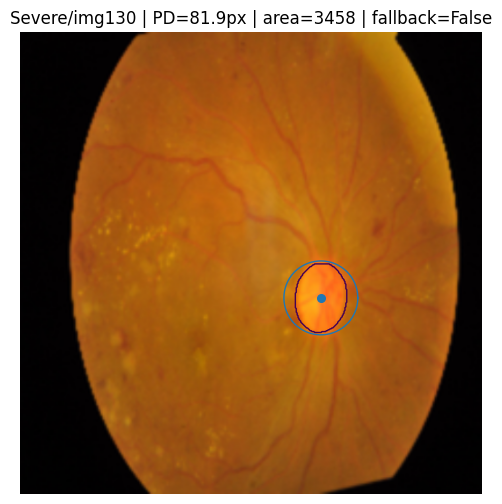

In [13]:
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
image_id = "Severe/img130"  # pick any existing

def safe_id(s): return s.replace("/", "__")

s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
s2 = CACHE_ROOT / RUN_ID_STAGE2 / "stage2" / safe_id(image_id)

rgb_iso = np.load(s1/"rgb_iso.npy")
disc = np.load(s2/"disc_mask.npy")
od = json.loads((s2/"od.json").read_text())
cy, cx = od["center_yx"]
PD = od["PD_px"]

plt.figure(figsize=(6,6))
plt.imshow(rgb_iso)
plt.contour(disc.astype(float), levels=[0.5], linewidths=1.0)
plt.scatter([cx],[cy], s=30)
# PD circle (radius = PD/2)
theta = np.linspace(0, 2*np.pi, 200)
r = PD/2.0
plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), linewidth=1.0)
plt.title(f"{image_id} | PD={PD:.1f}px | area={od['disc_area_px']} | fallback={od['fallback_used']}")
plt.axis("off")
plt.show()


In [14]:
import pandas as pd, json
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
s2root = CACHE_ROOT / RUN_ID_STAGE2 / "stage2"

rows = []
for d in s2root.iterdir():
    if not d.is_dir(): 
        continue
    od_path = d/"od.json"
    if od_path.exists():
        od = json.loads(od_path.read_text())
        rows.append({
            "image": d.name,
            "PD_px": od["PD_px"],
            "disc_area_px": od["disc_area_px"],
            "fallback_used": od["fallback_used"],
        })

df = pd.DataFrame(rows)
print(df.describe())
print("fallback rate:", df["fallback_used"].mean())
df.sort_values("PD_px").head(10)


             PD_px  disc_area_px
count  3665.000000   3665.000000
mean     83.766634   4533.655389
std       4.317760   1338.430853
min      81.920000      0.000000
25%      81.920000   3733.000000
50%      81.920000   4508.000000
75%      82.587797   5330.000000
max     113.770617  10166.000000
fallback rate: 0.008458390177353342


,image,PD_px,disc_area_px,fallback_used
17,Mild__img114,81.92,4388,False
3659,Severe__img94,81.92,4259,False
3660,Severe__img95,81.92,3310,False
3661,Severe__img96,81.92,3882,False
3662,Severe__img97,81.92,4647,False
2808,No_DR__img667,81.92,3837,False
2994,No_DR__img834,81.92,4474,False
2995,No_DR__img835,81.92,3495,False
2997,No_DR__img837,81.92,3852,False
2998,No_DR__img838,81.92,4375,False


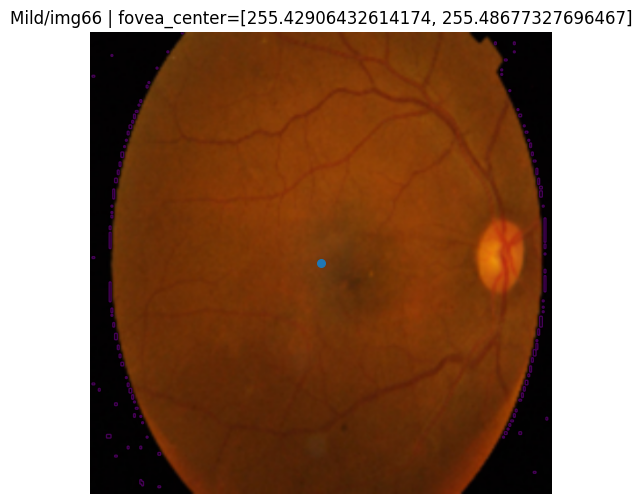

In [11]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
image_id = "Mild/img66"

def safe_id(s): return s.replace("/", "__")

s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
s2 = CACHE_ROOT / RUN_ID_STAGE2 / "stage2" / safe_id(image_id)

rgb_iso = np.load(s1/"rgb_iso.npy")
fovea = np.load(s1/"fovea_1hw.npy")[0] if (s1/"fovea_1hw.npy").exists() else None
fv = json.loads((s2/"fovea.json").read_text())["fovea_center_yx"]

plt.figure(figsize=(6,6))
plt.imshow(rgb_iso)
if fovea is not None:
    plt.contour(fovea.astype(float), levels=[0.5], linewidths=1.0)
if fv is not None:
    cy, cx = fv
    plt.scatter([cx],[cy], s=30)
plt.title(f"{image_id} | fovea_center={fv}")
plt.axis("off")
plt.show()
